In [1]:
# library
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns

In [11]:
# data loading
df_main = pd.read_csv('dataset_postur_v3.csv')
df_main.head()

,x1,y1,z1,v1,x2,y2,z2,v2,x3,y3,...,v31,x32,y32,z32,v32,x33,y33,z33,v33,class
0,0.473227,0.448671,-1.370094,0.999900,0.508110,0.371178,-1.296493,0.999825,0.531059,0.369569,...,0.005911,0.570819,3.512576,0.473188,0.005098,0.332951,3.503667,0.061031,0.005049,Normal
1,0.472680,0.446290,-1.283957,0.999923,0.504649,0.366265,-1.204633,0.999870,0.528109,0.364322,...,0.007211,0.642669,3.536009,0.234358,0.006502,0.379174,3.578034,-0.179240,0.006366,Normal
2,0.472032,0.440439,-1.287615,0.999944,0.504877,0.362192,-1.205525,0.999902,0.528598,0.361449,...,0.007102,0.645611,3.560929,0.253718,0.006470,0.384916,3.597208,-0.147204,0.006345,Normal
3,0.482949,0.455738,-1.253895,0.999783,0.519988,0.394538,-1.180284,0.999595,0.539186,0.395400,...,0.005899,0.596774,2.933085,0.266056,0.008639,0.383990,2.928932,0.007228,0.005854,Normal
4,0.481103,0.450878,-1.283996,0.999785,0.516970,0.388740,-1.210351,0.999628,0.536207,0.389822,...,0.005642,0.565652,2.956355,0.420726,0.007172,0.348007,2.989586,0.142858,0.006096,Normal


In [12]:
# cek proporsi data
df_main['class'].value_counts()

class
Normal     1458
Back       1244
Forward    1169
Name: count, dtype: int64

C:\Users\jason\AppData\Local\Temp\ipykernel_24296\3106249026.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='class', y='z11', ax=ax1, palette='pastel')
C:\Users\jason\AppData\Local\Temp\ipykernel_24296\3106249026.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='class', y='z12', ax=ax2, palette='pastel')


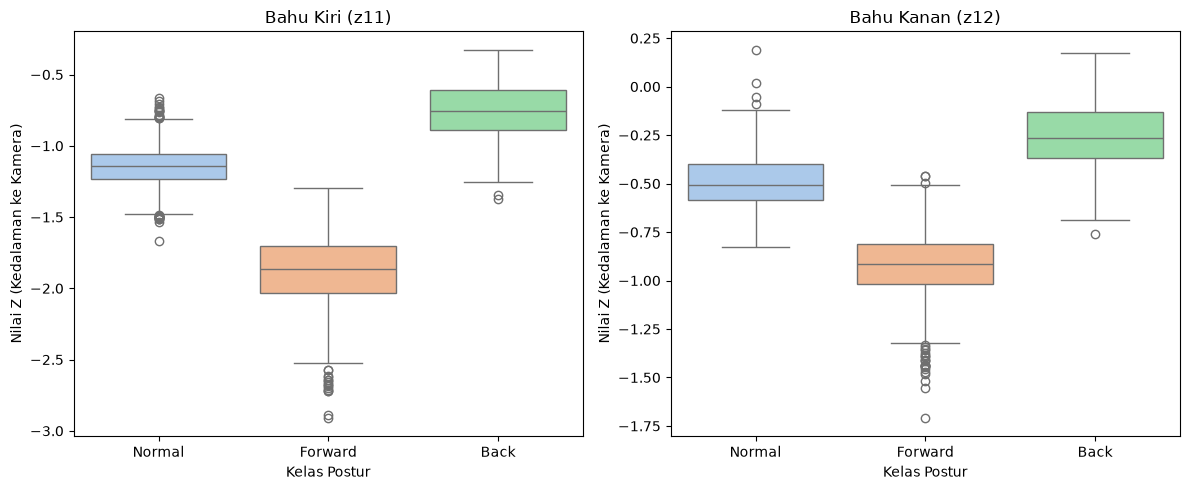

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_main, x='class', y='z11', ax=ax1, palette='pastel')
ax1.set_title('Bahu Kiri (z11)')
ax1.set_ylabel('Nilai Z (Kedalaman ke Kamera)')
ax1.set_xlabel('Kelas Postur')

# 3. Subplot Kanan: Bahu Kanan (z12)
sns.boxplot(data=df_main, x='class', y='z12', ax=ax2, palette='pastel')
ax2.set_title('Bahu Kanan (z12)')
ax2.set_ylabel('Nilai Z (Kedalaman ke Kamera)')
ax2.set_xlabel('Kelas Postur')

# Merapikan jarak antar grafik agar tidak berdempetan
plt.tight_layout()
plt.show()

C:\Users\jason\AppData\Local\Temp\ipykernel_24296\643948600.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='class', y='y2', ax=ax1, palette='pastel')
C:\Users\jason\AppData\Local\Temp\ipykernel_24296\643948600.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='class', y='y5', ax=ax2, palette='pastel')


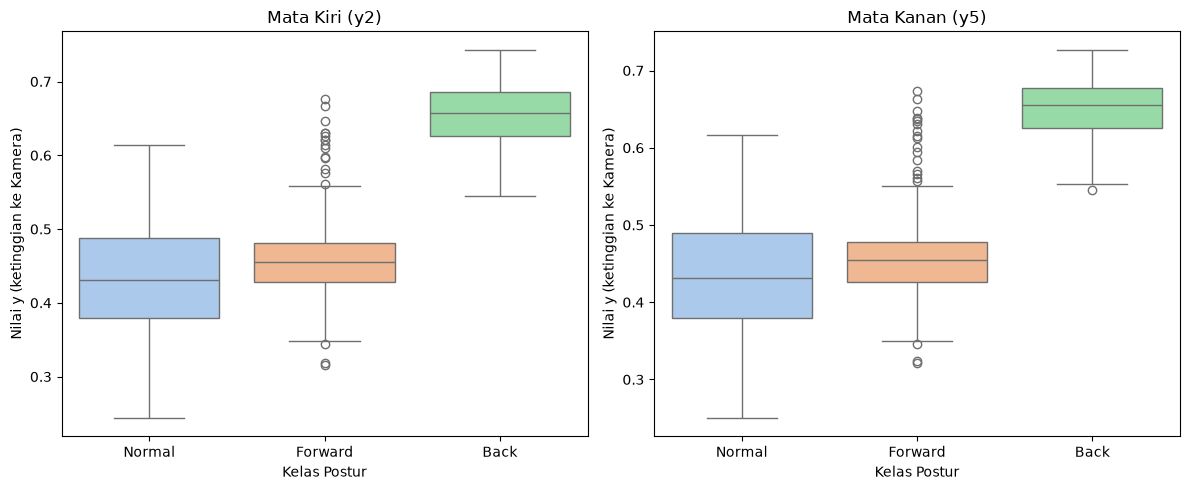

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# subplot kanan: Mata Kiri(y2)
sns.boxplot(data=df_main, x='class', y='y2', ax=ax1, palette='pastel')
ax1.set_title('Mata Kiri (y2)')
ax1.set_ylabel('Nilai y (ketinggian ke Kamera)')
ax1.set_xlabel('Kelas Postur')

# 3. Subplot Kanan: Mata Kanan (y5)
sns.boxplot(data=df_main, x='class', y='y5', ax=ax2, palette='pastel')
ax2.set_title('Mata Kanan (y5)')
ax2.set_ylabel('Nilai y (ketinggian ke Kamera)')
ax2.set_xlabel('Kelas Postur')

# Merapikan jarak antar grafik agar tidak berdempetan
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

print("Memuat dataset original...")
df = pd.read_csv('dataset_postur_v3.csv')

def remove_outliers_per_class(dataframe, columns):
    df_final = pd.DataFrame()
    
    # Pisahkan pembersihan untuk setiap kelas postur
    for posture in dataframe['class'].unique():
        df_class = dataframe[dataframe['class'] == posture].copy()
        
        for col in columns:
            Q1 = df_class[col].quantile(0.25)
            Q3 = df_class[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Filter hanya data yang wajar di kelas tersebut
            df_class = df_class[(df_class[col] >= lower_bound) & (df_class[col] <= upper_bound)]
            
        # Gabungkan kembali data yang sudah bersih
        df_final = pd.concat([df_final, df_class])
        
    return df_final

target_columns = ['y3', 'z3', 'y6', 'z6', 'y12', 'z12', 'y13', 'z13']

df_super_clean = remove_outliers_per_class(df, target_columns)

print(f"Data awal: {len(df)} baris.")
print(f"Data bersih: {len(df_super_clean)} baris.")

df_super_clean.to_csv('dataset_postur_clean.csv', index=False)
print("Save as 'dataset_postur_clean.csv'")

Memuat dataset original...
Data awal: 3871 baris.
Data bersih: 3747 baris.
Save as 'dataset_postur_clean.csv'


In [20]:
# load the cleaned data

df_clean = pd.read_csv('dataset_postur_clean.csv')
df_clean['class'].value_counts()

class
Normal     1392
Back       1238
Forward    1117
Name: count, dtype: int64

C:\Users\jason\AppData\Local\Temp\ipykernel_24296\2033277745.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='class', y='y2', ax=ax1, palette='pastel')
C:\Users\jason\AppData\Local\Temp\ipykernel_24296\2033277745.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='class', y='y5', ax=ax2, palette='pastel')


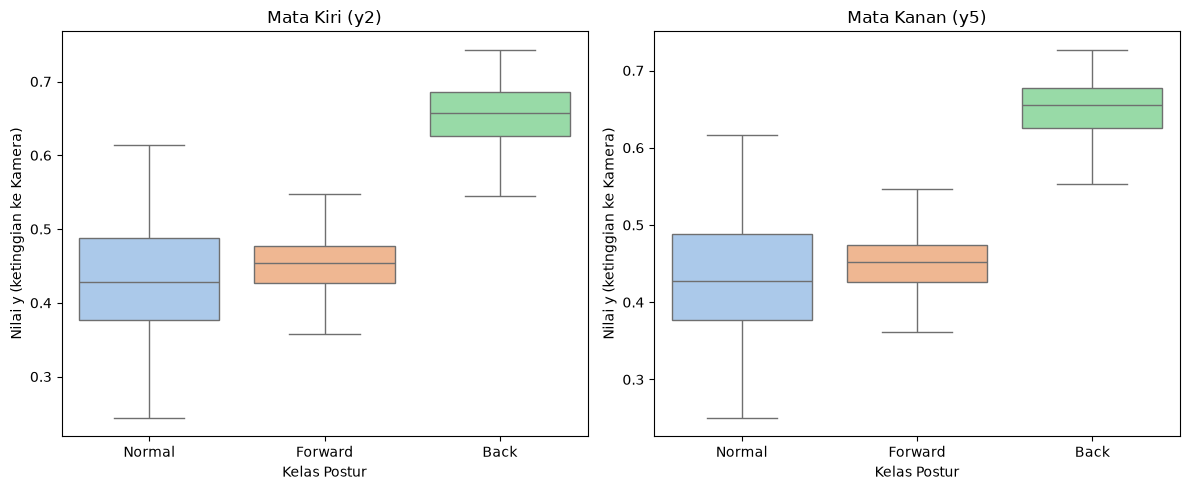

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# subplot kanan: Mata Kiri(y2)
sns.boxplot(data=df_clean, x='class', y='y2', ax=ax1, palette='pastel')
ax1.set_title('Mata Kiri (y2)')
ax1.set_ylabel('Nilai y (ketinggian ke Kamera)')
ax1.set_xlabel('Kelas Postur')

# 3. Subplot Kanan: Mata Kanan (y5)
sns.boxplot(data=df_clean, x='class', y='y5', ax=ax2, palette='pastel')
ax2.set_title('Mata Kanan (y5)')
ax2.set_ylabel('Nilai y (ketinggian ke Kamera)')
ax2.set_xlabel('Kelas Postur')

# Merapikan jarak antar grafik agar tidak berdempetan
plt.tight_layout()
plt.show()

C:\Users\jason\AppData\Local\Temp\ipykernel_24296\3519605707.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='class', y='z11', ax=ax1, palette='pastel')
C:\Users\jason\AppData\Local\Temp\ipykernel_24296\3519605707.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='class', y='z12', ax=ax2, palette='pastel')


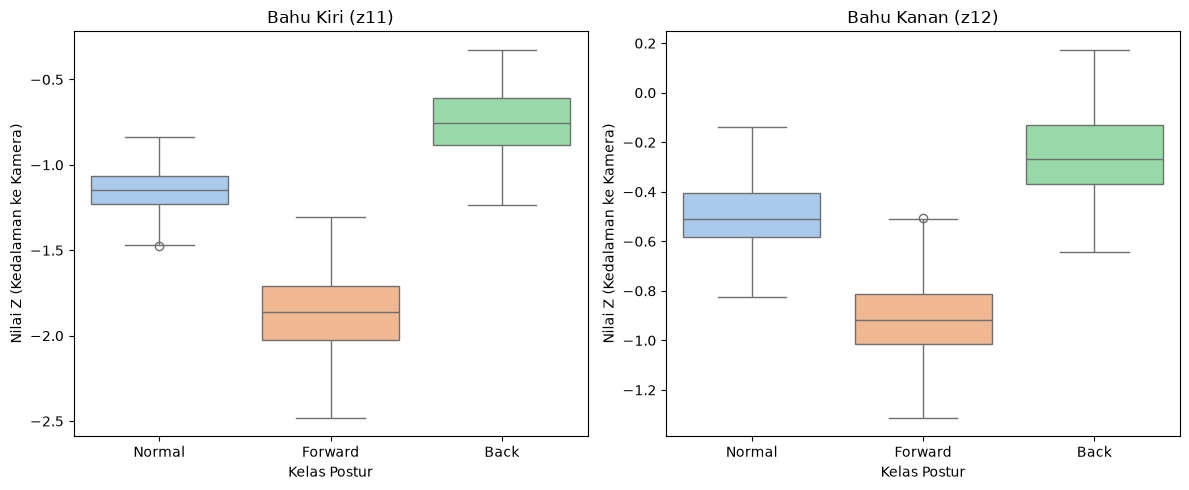

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_clean, x='class', y='z11', ax=ax1, palette='pastel')
ax1.set_title('Bahu Kiri (z11)')
ax1.set_ylabel('Nilai Z (Kedalaman ke Kamera)')
ax1.set_xlabel('Kelas Postur')

# 3. Subplot Kanan: Bahu Kanan (z12)
sns.boxplot(data=df_clean, x='class', y='z12', ax=ax2, palette='pastel')
ax2.set_title('Bahu Kanan (z12)')
ax2.set_ylabel('Nilai Z (Kedalaman ke Kamera)')
ax2.set_xlabel('Kelas Postur')

# Merapikan jarak antar grafik agar tidak berdempetan
plt.tight_layout()
plt.show()